# Building an Image Recognition System for Quality Control

### Import Libraries

In [4]:
!python -m pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- -------------------------

In [1]:
!python -m pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.3.0-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.83.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached m

### Import Libraries

In [28]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

data_path = Path(
    r"C:\Users\nidhi\Downloads\casting_512x512\casting_512x512"
)

output_path = Path(
    r"C:\Users\nidhi\Downloads\casting_split"
)

for folder in ["train", "validation", "test"]:
    for class_name in ["ok_front", "def_front"]:
        (output_path / folder / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

for class_name in ["ok_front", "def_front"]:

    class_path = data_path / class_name

    # Only actual image files
    images = [
        image for image in class_path.iterdir()
        if image.is_file()
    ]

    print(class_name, "total:", len(images))

    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    validation_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=42
    )

    for image in train_images:
        shutil.copy2(
            image,
            output_path / "train" / class_name / image.name
        )

    for image in validation_images:
        shutil.copy2(
            image,
            output_path / "validation" / class_name / image.name
        )

    for image in test_images:
        shutil.copy2(
            image,
            output_path / "test" / class_name / image.name
        )

print("Dataset split completed!")

ok_front total: 519
def_front total: 781
Dataset split completed!


In [2]:
import tensorflow as tf

image_size = (224, 224)
batch_size = 32

class_names = ["ok_front", "def_front"]

train_dataset = tf.keras.utils.image_dataset_from_directory(
    output_path / "train",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    output_path / "validation",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    output_path / "test",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

print("All datasets loaded!")

Found 909 files belonging to 2 classes.
Found 195 files belonging to 2 classes.
Found 196 files belonging to 2 classes.
All datasets loaded!


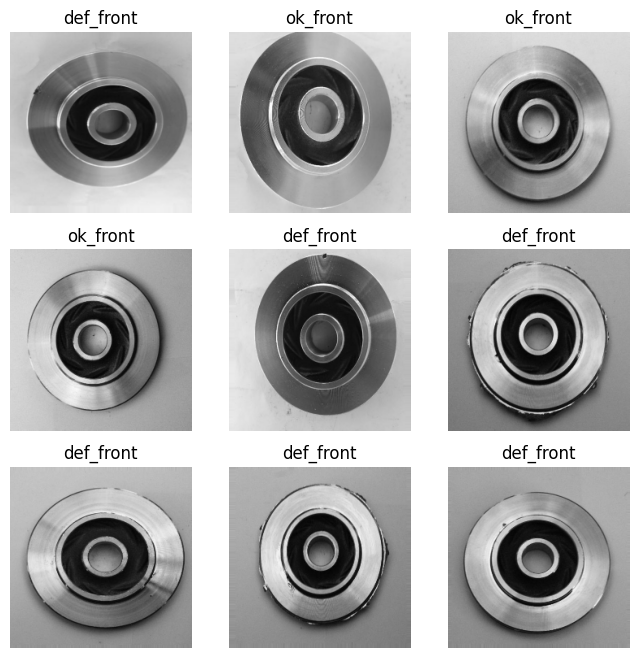

In [29]:
plt.figure(figsize=(8, 8))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[int(labels[i])])

        plt.axis("off")

plt.show()

In [30]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
])

print("Data augmentation ready!")

Data augmentation ready!


In [31]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1.0 / 255),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully!")

Model compiled successfully!


In [33]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_casting_defect_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks ready!")

Callbacks ready!


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/25


c:\Users\nidhi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 651ms/step - accuracy: 0.5842 - loss: 0.6871 - precision: 0.5968 - recall: 0.9487 - val_accuracy: 0.6000 - val_loss: 0.6728 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 601ms/step - accuracy: 0.6018 - loss: 0.6693 - precision: 0.6015 - recall: 0.9982 - val_accuracy: 0.6000 - val_loss: 0.6618 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 587ms/step - accuracy: 0.6007 - loss: 0.6605 - precision: 0.6007 - recall: 1.0000 - val_accuracy: 0.6000 - val_loss: 0.6460 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 594ms/step - accuracy: 0.6007 - loss: 0.6447 - precision: 0.6007 - recall: 1.0000 - val_accuracy: 0.6000 - val_loss: 0.6610 - val_precision: 0.6000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 586ms/step - accuracy: 0.6040

In [35]:
print("Epochs completed:", len(history.history["loss"]))

Epochs completed: 12


In [36]:
print("Number of epochs:", len(history.history["loss"]))
print("Best validation loss:", min(history.history["val_loss"]))
print("Best validation accuracy:", max(history.history["val_accuracy"]))

Number of epochs: 12
Best validation loss: 0.6154788732528687
Best validation accuracy: 0.620512843132019


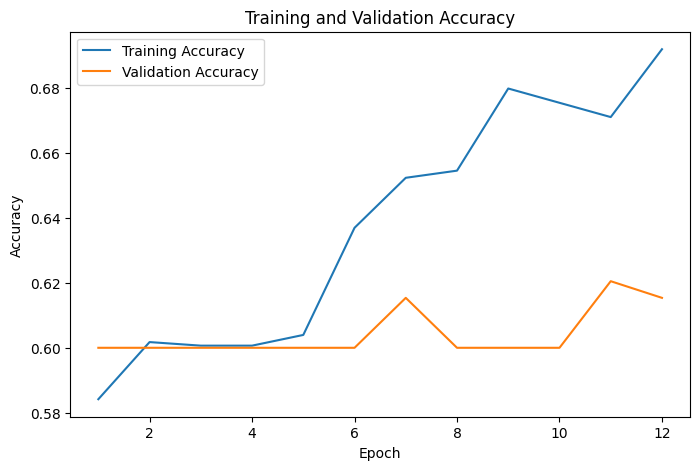

In [37]:
import numpy as np

training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

epochs = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    validation_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

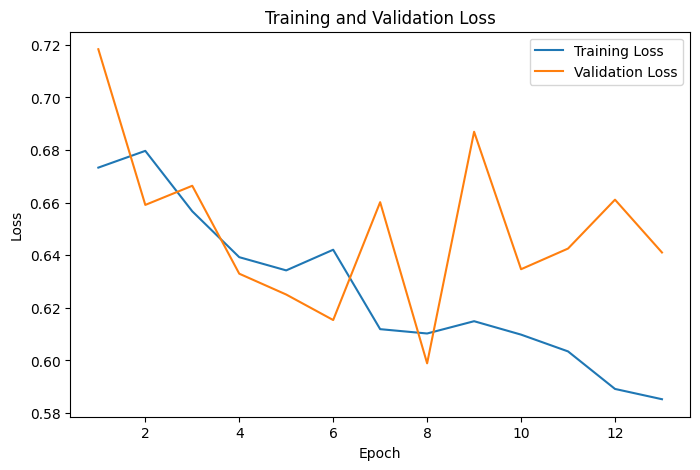

In [62]:
training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

In [38]:
test_results = model.evaluate(test_dataset)

print("Test Results:")
print(test_results)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.6224 - loss: 0.6035 - precision: 0.6146 - recall: 1.0000    
Test Results:
[0.6034783124923706, 0.6224489808082581, 0.6145833134651184, 1.0]


In [39]:
prediction_probabilities = model.predict(test_dataset)

predicted_labels = (
    prediction_probabilities.flatten() >= 0.5
).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

print("Predictions completed!")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step
Predictions completed!


In [40]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=[
            "Non-defective",
            "Defective"
        ]
    )
)

               precision    recall  f1-score   support

Non-defective       1.00      0.05      0.10        78
    Defective       0.61      1.00      0.76       118

     accuracy                           0.62       196
    macro avg       0.81      0.53      0.43       196
 weighted avg       0.77      0.62      0.50       196



Confusion Matrix:
[[  4  74]
 [  0 118]]


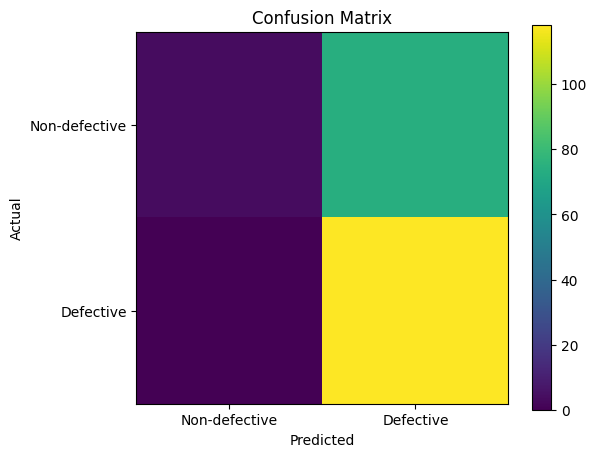

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
matrix = confusion_matrix(
    actual_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(matrix)

plt.figure(figsize=(6, 5))

plt.imshow(matrix)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Non-defective", "Defective"]
)

plt.yticks(
    [0, 1],
    ["Non-defective", "Defective"]
)

plt.colorbar()

plt.show()

In [42]:
tn, fp, fn, tp = matrix.ravel()

print("False Positive:", fp)
print("False Negative:", fn)

False Positive: 74
False Negative: 0


In [43]:
print("Test Accuracy:", test_results[1])
print("False Positive:", fp)
print("False Negative:", fn)

Test Accuracy: 0.6224489808082581
False Positive: 74
False Negative: 0


In [44]:
def predict_product(image_path):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)

    image_array = tf.expand_dims(
        image_array,
        axis=0
    )

    probability = float(
        model.predict(
            image_array,
            verbose=0
        )[0][0]
    )

    if probability >= 0.50:

        prediction = "Defective"
        action = "Send for manual inspection"

    else:

        prediction = "Non-defective"
        action = "Product may proceed"

    print("Prediction:", prediction)
    print("Defect probability:", f"{probability:.2%}")
    print("Recommended action:", action)

In [45]:
from pathlib import Path

folder = Path(
    r"C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front"
)

images = list(folder.glob("*"))

print("Images found:", len(images))

for image in images[:10]:
    print(image)

Images found: 519
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1018.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1021.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1028.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1074.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1082.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1083.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1091.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1092.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1102.jpeg
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1144.jpeg


In [46]:
image_path = str(images[0])

print("Testing image:")
print(image_path)

predict_product(image_path)

Testing image:
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\ok_front\cast_ok_0_1018.jpeg
Prediction: Defective
Defect probability: 52.08%
Recommended action: Send for manual inspection


In [47]:
def_folder = Path(
    r"C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\def_front"
)

def_images = list(def_folder.glob("*"))

print("Defective images found:", len(def_images))

image_path = str(def_images[0])

print("Testing image:")
print(image_path)

predict_product(image_path)

Defective images found: 781
Testing image:
C:\Users\nidhi\Downloads\casting_512x512\casting_512x512\def_front\cast_def_0_0.jpeg
Prediction: Defective
Defect probability: 84.51%
Recommended action: Send for manual inspection


### Design Decision Table

## Design Decisions and Reasons

| Design Choice | Selected Value | Reason |
|---|---|---|
| Image Size | 224 × 224 | Balances image detail and computational cost |
| Problem Type | Binary Classification | There are two classes: defective and non-defective |
| Model Type | CNN | CNN is suitable for image classification |
| Convolution Filters | 32, 64, 128 | Helps learn increasingly complex image features |
| Kernel Size | 3 × 3 | Effective for local feature extraction |
| Hidden Activation | ReLU | Efficient and commonly used for CNNs |
| Pooling | MaxPooling | Reduces feature dimensions and computation |
| Output Activation | Sigmoid | Produces probability for binary classification |
| Optimizer | Adam | Adaptive and beginner-friendly optimizer |
| Learning Rate | 0.001 | Reasonable starting value for Adam |
| Loss Function | Binary Cross-Entropy | Suitable for two-class classification |
| Batch Size | 32 | Provides a good balance between memory and training |
| Maximum Epochs | 25 | Allows sufficient training while Early Stopping prevents unnecessary training |
| Dropout | 0.40 | Helps reduce overfitting |
| Data Augmentation | Flip, Rotation, Zoom, Translation, Contrast | Improves model robustness to image variations |
| Evaluation Metrics | Accuracy, Precision, Recall | Measures overall and defective-class performance |

#### Summary of Design Choices

The CNN model was designed for binary classification of casting products into
defective and non-defective classes.

A 224 × 224 image size was selected to balance image detail and computational
requirements. Three convolutional layers with 32, 64 and 128 filters were used
to learn increasingly complex features.

ReLU activation was used in the hidden layers, while sigmoid activation was
used in the output layer because the problem contains two classes.

MaxPooling and Dropout were used to reduce computation and help control
overfitting. Data augmentation was applied to improve the model's robustness.

Adam optimizer with a learning rate of 0.001 and binary cross-entropy loss were
used for training. Accuracy, precision and recall were selected as evaluation
metrics.

### Training and Validation Accuracy Analysis

In [48]:

training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

print("Initial Training Accuracy:", training_accuracy[0])
print("Final Training Accuracy:", training_accuracy[-1])

print("Initial Validation Accuracy:", validation_accuracy[0])
print("Final Validation Accuracy:", validation_accuracy[-1])

accuracy_gap = abs(training_accuracy[-1] - validation_accuracy[-1])

print("Final Accuracy Gap:", accuracy_gap)

Initial Training Accuracy: 0.5841584205627441
Final Training Accuracy: 0.6919692158699036
Initial Validation Accuracy: 0.6000000238418579
Final Validation Accuracy: 0.6153846383094788
Final Accuracy Gap: 0.0765845775604248


### Accuracy & Loss Graphs

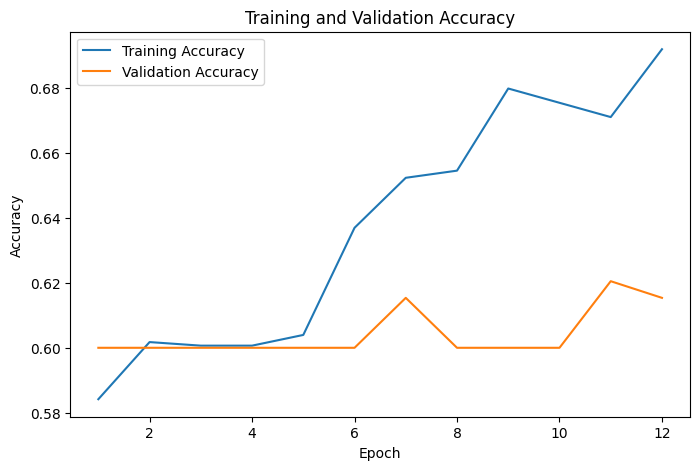

In [49]:
# Training and Validation Accuracy

epochs = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    validation_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

### Training and Validation Loss

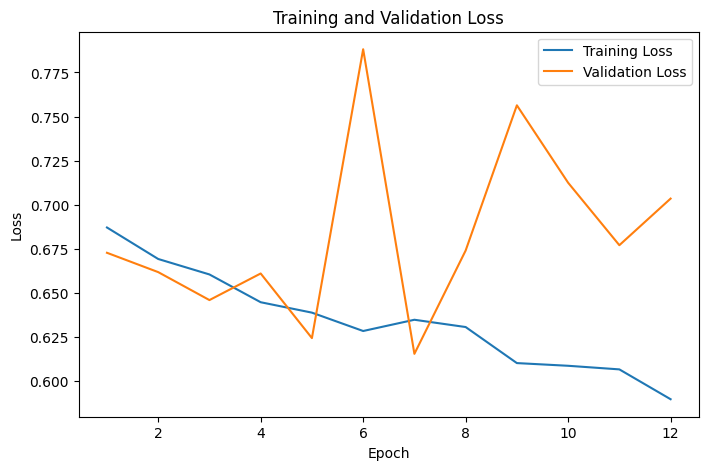

In [50]:

training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epochs = range(1, len(training_loss) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

### Test Dataset Evaluation

In [51]:
# Evaluate the model on the test dataset

test_results = model.evaluate(test_dataset)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])
print("Test Precision:", test_results[2])
print("Test Recall:", test_results[3])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.6224 - loss: 0.6035 - precision: 0.6146 - recall: 1.0000    
Test Loss: 0.6034783124923706
Test Accuracy: 0.6224489808082581
Test Precision: 0.6145833134651184
Test Recall: 1.0


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["Non-defective", "Defective"]
    )
)

               precision    recall  f1-score   support

Non-defective       1.00      0.05      0.10        78
    Defective       0.61      1.00      0.76       118

     accuracy                           0.62       196
    macro avg       0.81      0.53      0.43       196
 weighted avg       0.77      0.62      0.50       196



### Confusion Matrix

Confusion Matrix:
[[  4  74]
 [  0 118]]


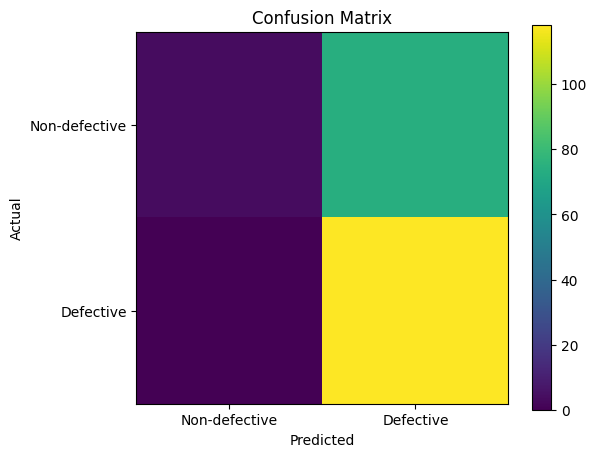

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

matrix = confusion_matrix(actual_labels, predicted_labels)

print("Confusion Matrix:")
print(matrix)

plt.figure(figsize=(6, 5))

plt.imshow(matrix)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Non-defective", "Defective"])
plt.yticks([0, 1], ["Non-defective", "Defective"])

plt.colorbar()
plt.show()

### False Positive & False Negative

In [54]:
# Calculate False Positive and False Negative

tn, fp, fn, tp = matrix.ravel()

print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)

True Negative: 4
False Positive: 74
False Negative: 0
True Positive: 118


### Why Recall for Defective Class Matters

## Why Recall for the Defective Class Matters

Recall is especially important for the defective class because a false negative
means that a defective product is incorrectly classified as non-defective.

In a quality-control system, this can be dangerous because the defective product
may pass inspection and reach the customer.

Therefore, a high recall for the defective class helps ensure that most defective
products are detected and sent for manual inspection.

In our model, the test recall is **100%**, which means all defective samples in
the test dataset were detected by the model.

### Test 5 Unseen Images

In [55]:
from pathlib import Path

# Test folders
test_ok_folder = Path(
    r"C:\Users\nidhi\Downloads\casting_split\test\ok_front"
)

test_def_folder = Path(
    r"C:\Users\nidhi\Downloads\casting_split\test\def_front"
)

# Get test images
ok_images = list(test_ok_folder.glob("*"))
def_images = list(test_def_folder.glob("*"))

# Select 3 non-defective + 2 defective images
selected_images = ok_images[:3] + def_images[:2]

print("Selected test images:", len(selected_images))

for image_path in selected_images:
    print(image_path)

Selected test images: 5
C:\Users\nidhi\Downloads\casting_split\test\ok_front\cast_ok_0_1234.jpeg
C:\Users\nidhi\Downloads\casting_split\test\ok_front\cast_ok_0_129.jpeg
C:\Users\nidhi\Downloads\casting_split\test\ok_front\cast_ok_0_1290.jpeg
C:\Users\nidhi\Downloads\casting_split\test\def_front\cast_def_0_1015.jpeg
C:\Users\nidhi\Downloads\casting_split\test\def_front\cast_def_0_1055.jpeg


### Prediction on 5 Unseen Test Images

In [56]:
print("5 Unseen Test Image Predictions")
print("-" * 60)

for image_path in selected_images:

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = tf.expand_dims(image_array, axis=0)

    probability = float(
        model.predict(image_array, verbose=0)[0][0]
    )

    if probability >= 0.50:
        prediction = "Defective"
        action = "Send for manual inspection"
    else:
        prediction = "Non-defective"
        action = "Product may proceed"

    print("Image:", image_path.name)
    print("Prediction:", prediction)
    print("Defect Probability:", f"{probability:.2%}")
    print("Recommended Action:", action)
    print("-" * 60)

5 Unseen Test Image Predictions
------------------------------------------------------------
Image: cast_ok_0_1234.jpeg
Prediction: Defective
Defect Probability: 75.76%
Recommended Action: Send for manual inspection
------------------------------------------------------------
Image: cast_ok_0_129.jpeg
Prediction: Defective
Defect Probability: 73.48%
Recommended Action: Send for manual inspection
------------------------------------------------------------
Image: cast_ok_0_1290.jpeg
Prediction: Defective
Defect Probability: 56.32%
Recommended Action: Send for manual inspection
------------------------------------------------------------
Image: cast_def_0_1015.jpeg
Prediction: Defective
Defect Probability: 76.49%
Recommended Action: Send for manual inspection
------------------------------------------------------------
Image: cast_def_0_1055.jpeg
Prediction: Defective
Defect Probability: 88.83%
Recommended Action: Send for manual inspection
-----------------------------------------------

### Five Unseen Test Images Results


The trained CNN model was tested on five unseen images from the test dataset.
For each image, the model provided a predicted class, defect probability,
and recommended action.

##### Decision Rule

- If defect probability is **≥ 50%** → **Defective**
- If defect probability is **< 50%** → **Non-defective**

For a defective prediction, the product is recommended for **manual inspection**.
For a non-defective prediction, the product **may proceed**.

The predictions demonstrate how the trained CNN model can be used as a
quality-control decision-support system for casting products.

### Final Model Performance Summary

The final CNN model was evaluated using the test dataset.

| Metric | Result |
|---|---:|
| Test Accuracy | 62.24% |
| Test Precision | 61.46% |
| Test Recall | 100% |
| Test Loss | 0.6035 |
| Best Validation Accuracy | 62.05% |
| Training Epochs Completed | 12 / 25 |

#### Performance Interpretation

The model achieved a test accuracy of approximately 62.24%.

The test recall for the defective class was 100%, which is important for
quality control because missing a defective product can allow it to pass
inspection.

The precision was approximately 61.46%, indicating that some products
classified as defective may actually be non-defective.

The model completed 12 epochs out of the maximum 25 epochs because
Early Stopping was used to prevent unnecessary training.

### Final Conclusion

The CNN model was developed to classify casting products into defective and
non-defective categories.

The model achieved a test accuracy of approximately **62.24%**, with a
precision of **61.46%** and a recall of **100%** for the defective class.

The high recall is important in a quality-control application because defective
products should not be incorrectly passed as non-defective.

The model also used data augmentation, dropout and Early Stopping to improve
robustness and reduce overfitting.

Overall, the developed CNN demonstrates the use of deep learning for automated
casting defect detection and can be used as a decision-support system for
industrial quality inspection. Further improvements could be achieved by
using a larger dataset, a more advanced CNN architecture and additional model
tuning.